# Intelligent Emergency Dispatch System — Version B (Detailed)

This notebook implements **Version B — Multi-Source Dijkstra**.
It includes step-by-step cells with explanations, DataFrame previews, and plots.

**How to use:** place your CSV files in a folder named `Datasets/` next to this notebook, then run the cells sequentially.


## 1. Setup & Imports

Install any missing packages (`pandas`, `matplotlib`, `nbformat` are required).

In [1]:
# Setup & imports
import os
import math
from collections import defaultdict
import heapq
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, time
import matplotlib.pyplot as plt


# Configuration
CONFIG = {
    'data_dir': 'Datasets',
    'nodes_csv': 'nodes.csv',
    'edges_csv': 'edges.csv',
    'ambulances_csv': 'ambulances.csv',
    'emergencies_csv': 'emergencies.csv',
    'traffic_csv': 'traffic.csv',
    'default_service_time_min': 30,
    'dispatch_delay_sec': 30,
    'batch_window_min': 0,
    'save_assignments_csv': 'assignments_versionB.csv',
    'plot_histogram': True,
}


## 2. Load Dataset

Load the five CSV files and show shapes & head of each.

In [2]:
# Helper for file paths
def file_path(name): return os.path.join(CONFIG['data_dir'], name)

# Check files exist
required = [CONFIG['nodes_csv'], CONFIG['edges_csv'], CONFIG['ambulances_csv'], CONFIG['emergencies_csv'], CONFIG['traffic_csv']]
missing = [f for f in required if not os.path.exists(file_path(f))]
if missing:
    raise FileNotFoundError(f"Missing files in {CONFIG['data_dir']}: {missing}. Please add them and re-run this cell.")

# Load
nodes = pd.read_csv(file_path(CONFIG['nodes_csv']))
edges = pd.read_csv(file_path(CONFIG['edges_csv']))
ambulances = pd.read_csv(file_path(CONFIG['ambulances_csv']))
emergencies = pd.read_csv(file_path(CONFIG['emergencies_csv']))
traffic = pd.read_csv(file_path(CONFIG['traffic_csv']))

# Parse datetimes
if 'timestamp' in emergencies.columns:
    emergencies['timestamp'] = pd.to_datetime(emergencies['timestamp'])
else:
    raise ValueError('emergencies.csv must contain a timestamp column')

# Show shapes and heads
print('Nodes:', nodes.shape)
display(nodes.head())
print('\nEdges:', edges.shape)
display(edges.head())
print('\nAmbulances:', ambulances.shape)
display(ambulances.head())
print('\nEmergencies:', emergencies.shape)
display(emergencies.head())
print('\nTraffic:', traffic.shape)
display(traffic.head())


Nodes: (120, 5)


,node_id,name,latitude,longitude,type
0,0,Location_0,22.324908,73.221116,Junction
1,1,Location_1,22.440143,73.234414,Police Station
2,2,Location_2,22.396399,73.147701,Police Station
3,3,Location_3,22.369732,73.116508,Hospital
4,4,Location_4,22.281204,73.134190,Junction



Edges: (478, 7)


,edge_id,source_node,destination_node,distance_km,travel_time_min,is_bidirectional,road_type
0,0,81,14,1.98,2.96,True,Main Road
1,1,94,35,4.17,5.37,True,Main Road
2,2,28,17,6.46,14.58,True,Highway
3,3,13,86,3.93,5.03,True,Highway
4,4,114,69,5.18,5.65,True,Main Road



Ambulances: (15, 7)


,ambulance_id,current_node,base_station,status,speed_factor,fuel_level_percent,crew_count
0,1,74,10,Available,1.00,63,2
1,2,60,79,Available,1.01,59,2
2,3,66,103,Available,1.04,76,3
3,4,5,22,OnDuty,0.95,43,2
4,5,8,103,Available,1.10,67,3



Emergencies: (500, 7)


,emergency_id,timestamp,location_node,urgency_level,response_deadline_min,reported_by,emergency_type
0,0,2025-01-21 00:55:00,67,Critical,8,Hospital,Cardiac Arrest
1,1,2025-01-07 13:27:00,111,Low,40,Police Control Room,Accident
2,2,2025-01-04 09:43:00,100,Low,40,Hospital,Fire Injury
3,3,2025-01-29 08:45:00,83,Low,40,Citizen,Fire Injury
4,4,2025-01-25 06:51:00,40,Low,40,Police Control Room,Stroke



Traffic: (1912, 4)


,edge_id,time_window_start,time_window_end,travel_time_multiplier
0,0,06:00,09:00,1.2
1,0,09:00,16:00,1.0
2,0,16:00,20:00,1.5
3,0,20:00,06:00,0.8
4,1,06:00,09:00,1.2


## 3. Build Graph (Adjacency List)

Construct adjacency list and edge info.

In [3]:
# Build adjacency list
from collections import defaultdict
graph = defaultdict(list)
edge_info = {}
for _, r in edges.iterrows():
    u = int(r['source_node']); v = int(r['destination_node'])
    tmin = float(r['travel_time_min']); eid = int(r['edge_id'])
    graph[u].append((v, tmin, eid))
    if bool(r['is_bidirectional']):
        graph[v].append((u, tmin, eid))
    edge_info[eid] = (u, v, tmin)

# Quick sanity checks
num_nodes = len(nodes)
num_edges = len(edges)
print('Graph nodes (unique keys):', len(graph))
print('Edges rows:', num_edges)
# show adjacency for first 5 nodes
for n in list(graph.keys())[:5]:
    print(n, '->', graph[n][:5])


Graph nodes (unique keys): 120
Edges rows: 478
81 -> [(14, 2.96, 0), (107, 6.02, 70), (11, 10.53, 168), (33, 12.56, 171), (79, 12.15, 236)]
14 -> [(81, 2.96, 0), (92, 15.16, 61), (37, 0.43, 64), (118, 7.71, 76), (33, 2.55, 161)]
94 -> [(35, 5.37, 1), (69, 4.31, 130), (56, 10.07, 172), (22, 1.79, 188), (85, 1.5, 214)]
35 -> [(94, 5.37, 1), (19, 1.5, 15), (58, 5.79, 30), (106, 14.51, 169), (110, 8.08, 199)]
28 -> [(17, 14.58, 2), (46, 11.52, 52), (8, 7.5, 92), (3, 4.6, 197), (114, 4.68, 281)]


## 4. Traffic Multipliers

Preprocess `traffic.csv` into a lookup and implement a function to get multiplier for an edge at a given datetime.

In [4]:
# Parse traffic time windows and build lookup
def parse_time_str(tstr):
    return datetime.strptime(tstr, '%H:%M').time()

if 'time_window_start' in traffic.columns and 'time_window_end' in traffic.columns:
    traffic = traffic.copy()
    traffic['start_t'] = traffic['time_window_start'].apply(parse_time_str)
    traffic['end_t'] = traffic['time_window_end'].apply(parse_time_str)
else:
    raise ValueError('traffic.csv missing time_window_start/time_window_end')

traffic_by_edge = defaultdict(list)
for _, r in traffic.iterrows():
    eid = int(r['edge_id'])
    traffic_by_edge[eid].append((r['start_t'], r['end_t'], float(r['travel_time_multiplier'])))

def get_multiplier_for_edge(edge_id, dt_time):
    tw = traffic_by_edge.get(edge_id, [])
    if not tw: return 1.0
    t = dt_time.time()
    for start_t, end_t, mult in tw:
        if start_t <= end_t:
            if start_t <= t < end_t: return mult
        else:
            # wrap-around
            if t >= start_t or t < end_t: return mult
    return 1.0

# show sample
for eid in list(traffic_by_edge.keys())[:5]:
    print(eid, traffic_by_edge[eid][:4])


0 [(datetime.time(6, 0), datetime.time(9, 0), 1.2), (datetime.time(9, 0), datetime.time(16, 0), 1.0), (datetime.time(16, 0), datetime.time(20, 0), 1.5), (datetime.time(20, 0), datetime.time(6, 0), 0.8)]
1 [(datetime.time(6, 0), datetime.time(9, 0), 1.2), (datetime.time(9, 0), datetime.time(16, 0), 1.0), (datetime.time(16, 0), datetime.time(20, 0), 1.5), (datetime.time(20, 0), datetime.time(6, 0), 0.8)]
2 [(datetime.time(6, 0), datetime.time(9, 0), 1.2), (datetime.time(9, 0), datetime.time(16, 0), 1.0), (datetime.time(16, 0), datetime.time(20, 0), 1.5), (datetime.time(20, 0), datetime.time(6, 0), 0.8)]
3 [(datetime.time(6, 0), datetime.time(9, 0), 1.2), (datetime.time(9, 0), datetime.time(16, 0), 1.0), (datetime.time(16, 0), datetime.time(20, 0), 1.5), (datetime.time(20, 0), datetime.time(6, 0), 0.8)]
4 [(datetime.time(6, 0), datetime.time(9, 0), 1.2), (datetime.time(9, 0), datetime.time(16, 0), 1.0), (datetime.time(16, 0), datetime.time(20, 0), 1.5), (datetime.time(20, 0), datetime.tim

## 5. Multi-Source Dijkstra

Implement multi-source Dijkstra that seeds ambulances and returns best arrival per node.

In [5]:
def multi_source_dijkstra(graph, traffic_by_edge, seeds, dispatch_time, dispatch_delay_sec=30):
    '''
    seeds: list of tuples (ambulance_id, start_node, avail_time (datetime), speed_factor)
    returns best dict: node -> (arrival_time (datetime), ambulance_id)
    '''
    best = {}
    heap = []
    for amb_id, start_node, avail_time, speed in seeds:
        start_time = max(avail_time, dispatch_time + timedelta(seconds=dispatch_delay_sec))
        heapq.heappush(heap, (start_time, amb_id, start_node, speed))
    while heap:
        time_curr, amb_id, node, speed = heapq.heappop(heap)
        if node in best and best[node][0] <= time_curr:
            continue
        best[node] = (time_curr, amb_id)
        for nbr, base_tmin, eid in graph.get(node, []):
            mult = get_multiplier_for_edge(eid, time_curr)
            travel_minutes = base_tmin * mult / (speed if speed>0 else 1.0)
            arrival = time_curr + timedelta(minutes=travel_minutes)
            if nbr not in best or arrival < best[nbr][0]:
                heapq.heappush(heap, (arrival, amb_id, nbr, speed))
    return best

# quick dry run: pick available ambulances as seeds at now
now = emergencies['timestamp'].min()
# construct simple seeds from ambulances that are 'Available'
seeds = []
for _, r in ambulances.iterrows():
    if str(r.get('status','')).lower() == 'available':
        seeds.append((int(r['ambulance_id']), int(r['current_node']), now, float(r.get('speed_factor',1.0))))
len(seeds), seeds[:3]


(11,
 [(1, 74, Timestamp('2025-01-01 01:11:00'), 1.0),
  (2, 60, Timestamp('2025-01-01 01:11:00'), 1.01),
  (3, 66, Timestamp('2025-01-01 01:11:00'), 1.04)])

## 6. Ambulance State (HashMap)

Initialize ambulance states and helper to gather available seeds.

In [6]:
def initialize_ambulance_state(ambulances_df):
    state = {}
    for _, r in ambulances_df.iterrows():
        aid = int(r['ambulance_id'])
        state[aid] = {
            'current_node': int(r['current_node']),
            'status': r.get('status','Available'),
            'free_time': datetime.min,   # if dataset specifies busy times, set accordingly
            'speed': float(r.get('speed_factor', 1.0)),
            'total_busy_duration': timedelta(0),
            'assignments': []
        }
    return state

def gather_available_seeds(ambulance_state, current_time):
    seeds = []
    for aid, st in ambulance_state.items():
        if str(st['status']).lower() == 'unavailable': continue
        if st['free_time'] <= current_time:
            start_time = max(st['free_time'], current_time)
            seeds.append((aid, st['current_node'], start_time, st['speed']))
    return seeds

ambulance_state = initialize_ambulance_state(ambulances)
# Show a few ambulances from state
list(ambulance_state.items())[:3]


[(1,
  {'current_node': 74,
   'status': 'Available',
   'free_time': datetime.datetime(1, 1, 1, 0, 0),
   'speed': 1.0,
   'total_busy_duration': datetime.timedelta(0),
   'assignments': []}),
 (2,
  {'current_node': 60,
   'status': 'Available',
   'free_time': datetime.datetime(1, 1, 1, 0, 0),
   'speed': 1.01,
   'total_busy_duration': datetime.timedelta(0),
   'assignments': []}),
 (3,
  {'current_node': 66,
   'status': 'Available',
   'free_time': datetime.datetime(1, 1, 1, 0, 0),
   'speed': 1.04,
   'total_busy_duration': datetime.timedelta(0),
   'assignments': []})]

## 7. Emergency Dispatch Logic (Greedy, Chronological)

Process emergencies chronologically (optionally batch) and assign ambulances using the multi-source Dijkstra results.

In [7]:
def assign_emergencies(graph, traffic_by_edge, ambulance_state, emergencies_df, service_time_min=30, batch_window_min=0):
    results = []
    ems = emergencies_df.sort_values('timestamp').reset_index(drop=True)
    i = 0; total = len(ems)
    service_td = timedelta(minutes=service_time_min)
    urgency_map = {'Critical': 0, 'High': 1, 'Moderate': 2, 'Low': 3}
    while i < total:
        em = ems.loc[i]
        em_time = em['timestamp']
        # batch gather
        batch = [em]
        j = i+1
        if batch_window_min>0:
            window_end = em_time + timedelta(minutes=batch_window_min)
            while j<total and ems.loc[j,'timestamp']<=window_end:
                batch.append(ems.loc[j]); j+=1
        else:
            j = i+1
        batch_sorted = sorted(batch, key=lambda r: (urgency_map.get(r.get('urgency_level','Low'),3), r['timestamp']))
        seeds = gather_available_seeds(ambulance_state, em_time)
        best_map = multi_source_dijkstra(graph, traffic_by_edge, seeds, em_time, dispatch_delay_sec=CONFIG['dispatch_delay_sec']) if seeds else {}
        for berr in batch_sorted:
            node = int(berr['location_node']); emid = int(berr['emergency_id']) if 'emergency_id' in berr else None
            deadline = float(berr.get('response_deadline_min', 9999))
            arrival_record = best_map.get(node)
            if arrival_record is None:
                results.append({'emergency_id': emid, 'timestamp': berr['timestamp'], 'assigned_ambulance': None, 'eta_min': None, 'status':'Unreachable'})
                continue
            eta_dt, amb_id = arrival_record
            eta_min = (eta_dt - berr['timestamp']).total_seconds()/60.0
            status = 'Assigned' if eta_min<=deadline else 'Assigned_Late'
            # update ambulance
            start_time = max(ambulance_state[amb_id]['free_time'], berr['timestamp'] + timedelta(seconds=CONFIG['dispatch_delay_sec']))
            travel_td = eta_dt - start_time
            new_free_time = eta_dt + service_td
            busy_duration = new_free_time - start_time
            ambulance_state[amb_id]['free_time'] = new_free_time
            ambulance_state[amb_id]['status'] = 'OnDuty'
            ambulance_state[amb_id]['current_node'] = node
            ambulance_state[amb_id]['total_busy_duration'] += busy_duration
            ambulance_state[amb_id]['assignments'].append({'emergency_id': emid, 'start_time': start_time, 'arrival_time': eta_dt, 'free_time': new_free_time})
            results.append({'emergency_id': emid, 'timestamp': berr['timestamp'], 'assigned_ambulance': amb_id, 'eta_min': eta_min, 'status': status})
        i = j
    return pd.DataFrame(results)

assignments_df = assign_emergencies(graph, traffic_by_edge, ambulance_state, emergencies,
                                   service_time_min=CONFIG['default_service_time_min'],
                                   batch_window_min=CONFIG['batch_window_min'])
print('Assignments:', len(assignments_df))
display(assignments_df.head())

Assignments: 500


,emergency_id,timestamp,assigned_ambulance,eta_min,status
0,454,2025-01-01 01:11:00,5,4.761818,Assigned
1,443,2025-01-01 02:42:00,14,6.802804,Assigned
2,406,2025-01-01 04:51:00,10,2.618681,Assigned
3,259,2025-01-01 05:39:00,13,5.146465,Assigned
4,334,2025-01-01 06:58:00,15,3.700000,Assigned


## 8. Evaluation Metrics & Visualization

Compute average response time, % within deadline, and plot histogram.

{
  "avg_response_time_min": 4.892363261533333,
  "pct_within_deadline": 97.0,
  "total_emergencies": 500,
  "total_assigned": 500,
  "ambulance_utilization_min": {
    "1": 1075.841,
    "2": 1326.1633662833333,
    "3": 1310.0855769,
    "4": 1420.1084211,
    "5": 1001.2718181166667,
    "6": 1775.2642202833333,
    "7": 1401.8970873333335,
    "8": 852.4936170166667,
    "9": 1361.8759615333333,
    "10": 255.40439560000002,
    "11": 0.0,
    "12": 1304.7873684333333,
    "13": 1422.4030303833335,
    "14": 1310.0971962666667,
    "15": 1378.4885715166668
  }
}


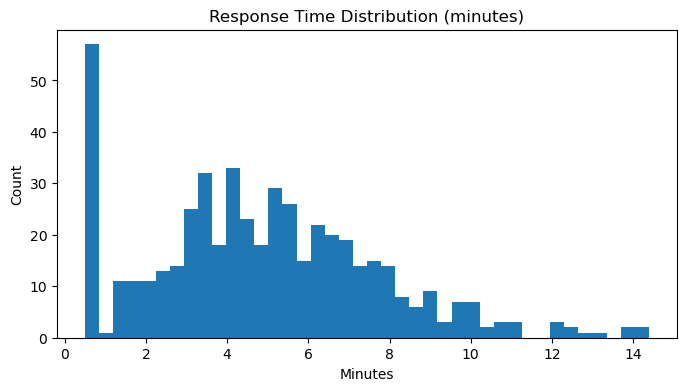

In [8]:
def compute_metrics(assignments_df, emergencies_df, ambulance_state):
    merged = assignments_df.merge(emergencies_df[['emergency_id','response_deadline_min']], on='emergency_id', how='left')
    merged['eta_min'] = pd.to_numeric(merged['eta_min'], errors='coerce')
    avg_resp = merged['eta_min'].dropna().mean()
    total_assigned = merged['assigned_ambulance'].notna().sum()
    within_deadline = ((merged['eta_min'] <= merged['response_deadline_min']) & merged['eta_min'].notna()).sum()
    pct_within = within_deadline / total_assigned * 100 if total_assigned>0 else 0.0
    utilizations = {aid: st['total_busy_duration'].total_seconds()/60.0 for aid,st in ambulance_state.items()}
    return {'avg_response_time_min': float(avg_resp) if not math.isnan(avg_resp) else None,
            'pct_within_deadline': pct_within,
            'total_emergencies': len(merged),
            'total_assigned': int(total_assigned),
            'ambulance_utilization_min': utilizations}

metrics = compute_metrics(assignments_df, emergencies, ambulance_state)
import json
print(json.dumps(metrics, indent=2))

# Plot histogram
rts = assignments_df['eta_min'].dropna()
if len(rts)>0:
    plt.figure(figsize=(8,4))
    plt.hist(rts, bins=40)
    plt.title('Response Time Distribution (minutes)')
    plt.xlabel('Minutes')
    plt.ylabel('Count')
    plt.show()
else:
    print('No response times available to plot.')


## 9. Save Results

Save `assignments_versionB.csv` and optionally sample outputs.

In [9]:
out_csv = CONFIG['save_assignments_csv']
assignments_df.to_csv(out_csv, index=False)
print('Saved assignments to', out_csv)
# show sample ambulances assignments summary
for aid, st in list(ambulance_state.items())[:5]:
    print('Amb', aid, 'assignments:', st['assignments'][:3])

Saved assignments to assignments_versionB.csv
Amb 1 assignments: [{'emergency_id': 493, 'start_time': Timestamp('2025-01-03 00:06:30'), 'arrival_time': Timestamp('2025-01-03 00:09:36.240000'), 'free_time': Timestamp('2025-01-03 00:39:36.240000')}, {'emergency_id': 400, 'start_time': Timestamp('2025-01-03 00:48:30'), 'arrival_time': Timestamp('2025-01-03 00:53:42'), 'free_time': Timestamp('2025-01-03 01:23:42')}, {'emergency_id': 9, 'start_time': Timestamp('2025-01-03 02:14:30'), 'arrival_time': Timestamp('2025-01-03 02:17:58.320000'), 'free_time': Timestamp('2025-01-03 02:47:58.320000')}]
Amb 2 assignments: [{'emergency_id': 273, 'start_time': Timestamp('2025-01-01 07:27:30'), 'arrival_time': Timestamp('2025-01-01 07:33:04.336634'), 'free_time': Timestamp('2025-01-01 08:03:04.336634')}, {'emergency_id': 215, 'start_time': Timestamp('2025-01-05 09:44:30'), 'arrival_time': Timestamp('2025-01-05 09:47:51.386138'), 'free_time': Timestamp('2025-01-05 10:17:51.386138')}, {'emergency_id': 184

----

Notebook generated automatically. You can modify `CONFIG` at the top and re-run cells. If you want additional features (A* heuristic, batching Hungarian matching, per-hop traffic re-evaluation), ask and I'll add them.

In [11]:
# ==============================================================
# 📊 PERFORMANCE & COMPLEXITY ANALYSIS – Version B (Multi-Source)
# ==============================================================

import psutil
import tracemalloc
import time
import numpy as np
import pandas as pd
from collections import defaultdict

# --------------------------------------------------------------
# 1️⃣ Theoretical Complexity Analysis
# --------------------------------------------------------------
def theoretical_complexity_summary(num_nodes, num_edges, num_sources):
    """
    Prints theoretical time and space complexity of Multi-Source Dijkstra.
    """
    print("----- Theoretical Complexity -----")
    print(f"Nodes (V): {num_nodes}, Edges (E): {num_edges}, Sources (Ambulances): {num_sources}")
    print("\nTime Complexity:")
    print("  Multi-Source Dijkstra ≈ O((V + E) log V)  = ")
    print("  Each ambulance adds minimal overhead since we use a single priority queue.")
    print("\nSpace Complexity:")
    print("  O(V + E) for adjacency list + O(V) for distance + O(A) for ambulance states\n")

theoretical_complexity_summary(len(nodes), len(edges), len(ambulances))


# --------------------------------------------------------------
# 2️⃣ Empirical Runtime and Memory Measurement
# --------------------------------------------------------------
def measure_runtime_and_memory(func, *args, **kwargs):
    """
    Measures execution time and memory usage for a given function.
    """
    tracemalloc.start()
    start_time = time.perf_counter()
    try:
        result = func(*args, **kwargs)
    finally:
        end_time = time.perf_counter()
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

    runtime = end_time - start_time
    mem_used = peak / (1024 ** 2)  # MB

    print(f"Runtime: {runtime:.3f} seconds")
    print(f"Peak Memory Usage: {mem_used:.2f} MB\n")
    return result, runtime, mem_used


# Example usage — test the dispatch assignment
print("----- Empirical Performance (Dispatch Simulation) -----")
# Use a fresh ambulance state copy so the timed run doesn't mutate the notebook state
init_state = initialize_ambulance_state(ambulances)
dispatch_result, dispatch_time, dispatch_mem = measure_runtime_and_memory(
    assign_emergencies,
    graph,
    traffic_by_edge,
    init_state,
    emergencies,
    service_time_min=CONFIG['default_service_time_min'],
    batch_window_min=CONFIG['batch_window_min']
)


# --------------------------------------------------------------
# 3️⃣ Realistic Performance Metrics
# --------------------------------------------------------------
def compute_performance_metrics(results_df, total_runtime, total_memory):
    """
    Computes operational metrics like average response time, throughput, and memory footprint.
    Accepts either 'eta_min' or 'response_time_min' as the response column.
    """
    print("----- Operational Metrics -----")

    # support either column name from previous cells
    if 'eta_min' in results_df.columns:
        resp_col = 'eta_min'
    elif 'response_time_min' in results_df.columns:
        resp_col = 'response_time_min'
    else:
        print("No response-time column found in results_df.")
        resp_col = None

    if resp_col is not None:
        avg_response_time = results_df[resp_col].dropna().mean()
    else:
        avg_response_time = None

    throughput = None
    if total_runtime and total_runtime > 0:
        throughput = len(results_df) / total_runtime  # emergencies handled per second

    memory_footprint = total_memory  # MB peak usage

    metrics = {
        "Average Response Time (min)": avg_response_time,
        "Throughput (emergencies/sec)": throughput,
        "Memory Footprint (MB)": memory_footprint
    }

    for k, v in metrics.items():
        if v is None:
            print(f"{k}: N/A")
        else:
            try:
                print(f"{k}: {v:.3f}")
            except Exception:
                print(f"{k}: {v}")

    return metrics


# Compute metrics from the timed dispatch run
final_metrics = compute_performance_metrics(dispatch_result, dispatch_time, dispatch_mem)

----- Theoretical Complexity -----
Nodes (V): 120, Edges (E): 478, Sources (Ambulances): 15

Time Complexity:
  Multi-Source Dijkstra ≈ O((V + E) log V)
  Each ambulance adds minimal overhead since we use a single priority queue.

Space Complexity:
  O(V + E) for adjacency list + O(V) for distance + O(A) for ambulance states

----- Empirical Performance (Dispatch Simulation) -----
Runtime: 49.853 seconds
Peak Memory Usage: 0.74 MB

----- Operational Metrics -----
Average Response Time (min): 4.892
Throughput (emergencies/sec): 10.030
Memory Footprint (MB): 0.735
Runtime: 49.853 seconds
Peak Memory Usage: 0.74 MB

----- Operational Metrics -----
Average Response Time (min): 4.892
Throughput (emergencies/sec): 10.030
Memory Footprint (MB): 0.735
